# Anomaly Time Series 

## Introduction

Climate datasets often contain strong seasonal cycles that can obscure the variability we are interested in studying. For variables such as zonal wind, sea surface temperature (SST), and outgoing longwave radiation (OLR), the mean seasonal cycle reflects predictable changes associated with the annual march of solar heating, atmospheric circulation, ocean warming and cooling, and tropical convection.

To focus on departures from the expected seasonal state, we calculate anomaly time series. An anomaly is defined as the difference between the observed value and a climatological seasonal mean:

$$
\text{anomaly} = \text{observed value} - \text{seasonal climatology}.
$$

These anomalies are useful for studying intraseasonal and interannual variability, such as the Madden-Julian Oscillation (MJO), ENSO-related variability, and other tropical circulation changes.

Although this workflow can be applied to multiple climate variables, including zonal wind, SST, and OLR, this notebook demonstrates the method using **850 hPa zonal wind** from the NCEP–NCAR Reanalysis dataset. The 850 hPa level is commonly used to represent lower-tropospheric tropical circulation. We calculate anomalies by removing the seasonal cycle using two approaches:

1. **Daily climatology** — subtracting the average value for each calendar day.
2. **Harmonic regression** — fitting and subtracting a smooth seasonal cycle using annual harmonics.

The resulting anomaly time series can then be inspected and compared to evaluate how each method removes the seasonal cycle through several steps:

1. Basic inspection
2. Compare time series at one grid point
3. Differences between two methods
4. Compare regional-mean anomaly time series
5. Check near-zero mean
6. Check remaining seasonal cycle
7. Compute correlation and RMSE between methods


---

## Download the NCEP-NCAR Reanalysis Data
First, we are going to download the necessary daily Zonal Wind and Geopotential Height dataset from the NCEP-NCAR Reanalysis from 1979 to 2025:

### Imports

In [6]:
import s3fs
import xarray as xr

Create S3 filesystem

In [7]:
URL = 'https://js2.jetstream-cloud.org:8001/' #Locate and read a file
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))

### Dataset information
Let's import the neccesary modules:

In [8]:
import xarray as xr
import numpy as np

Create mappers to the Zarr stores

In [9]:
uwind_ncep_ncar_store = s3fs.S3Map(
    root=f'pythia/uwind-ncep-ncar.zarr',
    s3=fs,
    check=False
)

Create Xarray Datasets for uwind

In [10]:
uwind_ncep_ncar = xr.open_zarr(uwind_ncep_ncar_store)
uwind_ncep_ncar

<xarray.Dataset> Size: 495MB
Dimensions:  (lat: 25, level: 2, lon: 144, time: 17167)
Coordinates:
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * level    (level) float32 8B 850.0 200.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
Data variables:
    uwnd     (time, level, lat, lon) float32 494MB dask.array<chunksize=(1024, 2, 25, 144), meta=np.ndarray>

:::{note}
The Real-time Multivariate MJO (RMM) index [(Wheeler and Hendon 2004)](https://journals.ametsoc.org/view/journals/mwre/132/8/1520-0493_2004_132_1917_aarmmi_2.0.co_2.xml) tracks the Madden–Julian Oscillation from the leading pair of empirical orthogonal functions (EOFs) of equatorial outgoing longwave radiation (OLR) and 850- and 200-hPa zonal wind. Hence, the zonal wind has already been preprocessed in this dataset 
:::

To quickly see how the plot looks like (for instance, uwind at 850 millibar on Jan 1, 1979)

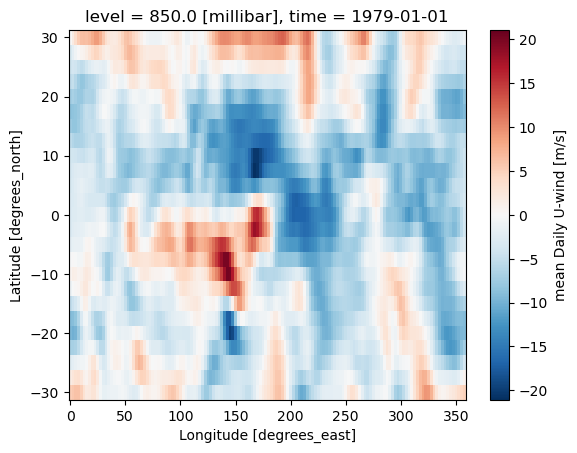

In [22]:
uwind_ncep_ncar.uwnd.isel(level=0, time=0).plot()

If you want to speculate OLR data:

In [82]:
import xarray as xr
import numpy as np

olr_noaa_store = s3fs.S3Map(
    root=f'pythia/olr_noaa.zarr',
    s3=fs,
    check=False
)

# Open with xarray
olr_noaa = xr.open_zarr(olr_noaa_store)
olr_noaa

<xarray.Dataset> Size: 242MB
Dimensions:                        (time: 16802, lat: 25, lon: 144)
Coordinates:
  * lat                            (lat) float32 100B 30.0 27.5 ... -27.5 -30.0
  * lon                            (lon) float32 576B 0.0 2.5 ... 355.0 357.5
  * time                           (time) datetime64[ns] 134kB 1979-01-01T12:...
Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float32 242MB dask.array<chunksize=(1024, 25, 144), meta=np.ndarray>

## Remove the Seasonal Cycle

### Daily Climatology

Tropical zonal-wind variability lives on top of a strong annual cycle driven by the seasonal march of insolation. To isolate the intraseasonal and interannual signals we are interested in (e.g. the MJO, ENSO teleconnections), we first fit and subtract a smooth seasonal climatology at every grid point.

The traditional method of getting the anomalies is to compute a day-of-year mean (e.g. average all January 1sts, all January 2nds, …) and subtract that.

In [22]:
def remove_seasonal_cycle_daily_climatology(da, drop_feb29=True):
    """
    Remove the seasonal cycle using traditional daily climatology.

    Parameters
    ----------
    da : xarray.DataArray
        Input data with a time dimension.
    drop_feb29 : bool
        If True, remove February 29 before computing anomalies.

    Returns
    -------
    anomalies : xarray.DataArray
        Data with daily climatological seasonal cycle removed.
    climatology : xarray.DataArray
        Daily climatology indexed by month_day.
    """

    # Create month-day coordinate, e.g. "01-01", "01-02", ...
    month_day = da["time"].dt.strftime("%m-%d")
    da = da.assign_coords(month_day=("time", month_day.data))

    # Optionally remove leap day
    if drop_feb29:
        da = da.where(da["month_day"] != "02-29", drop=True)

    # Compute daily climatology
    climatology = da.groupby("month_day").mean("time")

    # Subtract climatology from each matching calendar day
    anomalies = da.groupby("month_day") - climatology

    return anomalies, climatology

Apply this to 850 hPa zonal wind:

In [27]:
# Select the uwnd DataArray
uwind = uwind_ncep_ncar["uwnd"]

# Select 850 hPa
uwind_850_da = (
    uwind
    .sel(level=850)
    .drop_vars("level", errors="ignore")
)

# Remove the seasonal cycle using daily climatology
uwind_850_anomalies_da, uwind_850_daily_clim = remove_seasonal_cycle_daily_climatology(
    uwind_850_da
)

# Update metadata
uwind_850_anomalies_da.attrs = uwind_850_da.attrs.copy()
uwind_850_anomalies_da.attrs["long_name"] = (
    uwind_850_da.attrs.get("long_name", "850 hPa zonal wind") + " anomalies"
)

# Convert anomalies to Dataset
uwind_850_anomalies_daily_ds = uwind_850_anomalies_da.to_dataset(
    name="uwnd_anom"
)

uwind_850_anomalies_daily_ds

<xarray.Dataset> Size: 247MB
Dimensions:    (lat: 25, lon: 144, time: 17155)
Coordinates:
  * lat        (lat) float32 100B 30.0 27.5 25.0 22.5 ... -25.0 -27.5 -30.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
    month_day  (time) object 137kB '01-01' '01-02' '01-03' ... '12-30' '12-31'
Data variables:
    uwnd_anom  (time, lat, lon) float32 247MB dask.array<chunksize=(365, 25, 144), meta=np.ndarray>

## Harmonic Regression and Why is it better?

A common alternative is to compute a day-of-year mean (e.g. average all January 1sts, all January 2nds, …) and subtract that. Harmonic regression with a small $N$ has two advantages:

- **Smoothness.** It produces a continuous, low-pass seasonal cycle and avoids the day-to-day noise of a raw daily climatology.
- **Robustness.** With only $2N + 1$ parameters per grid point, it is far less prone to overfitting short records.

Choosing $N = 4$ (`n_harmonics`)retains the annual, semi-annual, and the first two higher harmonics, which is enough to capture the main seasonal shape of tropical winds while filtering out higher-frequency noise that we want to keep in the anomalies.

### The model

For each grid point we model the time series $u(t)$ as a constant plus a sum of $N$ harmonics of the annual cycle:

$$
u(t) \approx a_0 + \sum_{k=1}^{N} \left[ a_k \sin(2\pi kt/T) + b_k \cos(2\pi kt/T) \right],
$$

where $T = 365.25$ days is the period of one year and $N$ (`n_harmonics`, default 4) controls how sharp the seasonal shape can be. The first harmonic ($k = 1$) is the pure annual cycle; $k = 2$ adds a semi-annual component; higher $k$ allow progressively narrower seasonal features.

In [12]:
def remove_seasonal_cycle_harmonic(data, n_harmonics=4, year_period=365.25):
    """
    Remove seasonal cycle using harmonic regression.
    
    Parameters:
    -----------
    data : ndarray
        3D array with shape (time, lat, lon). No NaN values.
    n_harmonics : int
        Number of harmonic pairs (sin/cos) to fit (default: 4)
    year_period : float
        Period of the seasonal cycle in time units (default: 365.25 days)
    
    Returns:
    --------
    anomalies : ndarray
        Data with seasonal cycle removed, same shape as input
    """

    n_time, n_lat, n_lon = data.shape
    data_2d = data.reshape(n_time, -1)

    # Build design matrix: 1 constant + n_harmonics sin/cos pairs
    t = np.arange(n_time)
    X = np.ones((n_time, 2 * n_harmonics + 1))
    for i in range(1, n_harmonics + 1):
        X[:, 2*i - 1] = np.sin(i * 2 * np.pi * t / year_period)
        X[:, 2*i] = np.cos(i * 2 * np.pi * t / year_period)

    # Solve via least squares and subtract seasonal component
    coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]
    anomalies = data_2d - X @ coeffs

    return anomalies.reshape(n_time, n_lat, n_lon)

In [24]:
# Extract the 850 and 200 hPa zonal winds
import dask
# uwind_850 = dask.compute(uwind_ncep_ncar.sel(level=850).data)[0]
uwind_850 = dask.compute(uwind_ncep_ncar["uwnd"].sel(level=850).data)[0]
uwind_200 = dask.compute(uwind_ncep_ncar["uwnd"].sel(level=200).data)[0]

In [30]:
# Select the DataArray first
uwind = uwind_ncep_ncar["uwnd"]

# Select 850 hPa
uwind_850_da = (
    uwind
    .sel(level=850)
    .drop_vars("level", errors="ignore")
    .load()
)

# Remove the seasonal cycle
uwind_850_anomalies = remove_seasonal_cycle_harmonic(uwind_850_da.values)

# Create a DataArray with the anomalies
uwind_850_anomalies_da = uwind_850_da.copy(
    data=uwind_850_anomalies
)

# Update attributes safely
uwind_850_anomalies_da.attrs["long_name"] = (
    uwind_850_da.attrs.get("long_name", "850 hPa zonal wind") + " anomalies"
)

# Convert to Dataset
uwind_850_anomalies_harmonic_ds = uwind_850_anomalies_da.to_dataset(
    name="uwnd_anom"
)

uwind_850_anomalies_harmonic_ds

<xarray.Dataset> Size: 495MB
Dimensions:    (lat: 25, lon: 144, time: 17167)
Coordinates:
  * lat        (lat) float32 100B 30.0 27.5 25.0 22.5 ... -25.0 -27.5 -30.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
Data variables:
    uwnd_anom  (time, lat, lon) float64 494MB 1.142 2.934 4.368 ... 8.243 4.796

## Inspect the anomaly time series

After computing anomalies with both methods, we compare their behavior at individual grid points and over a regional average. We also check that the seasonal cycle has been removed.

Let's see what the figures look like for both daily climatology and harmonic regression methods for one day (in this case, Jan 11, 1979).

First of all, let's extract the variables first since they are stored in the dataset: 

In [41]:
daily_anom = uwind_850_anomalies_daily_ds["uwnd_anom"]
harmonic_anom = uwind_850_anomalies_harmonic_ds["uwnd_anom"]

### I. Basic inspection

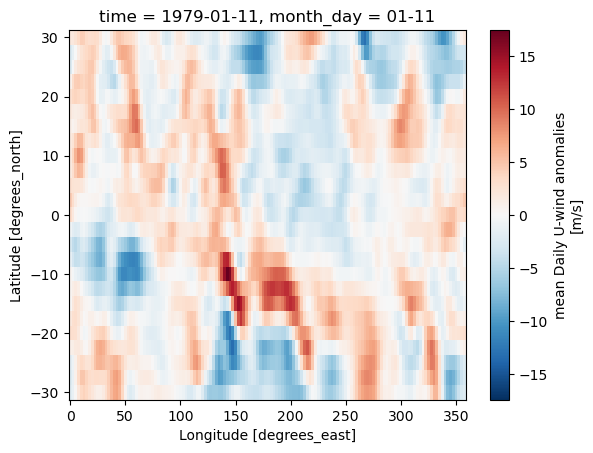

In [42]:
daily_anom.isel(time=10).plot()

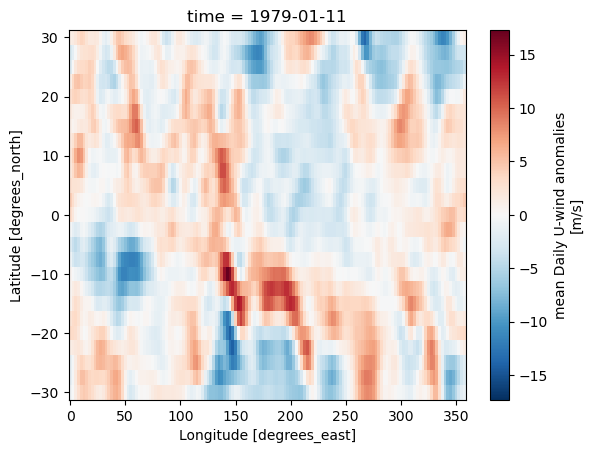

In [43]:
harmonic_anom.isel(time=10).plot()

### II. Compare time series at one grid point

Then we compare them at each grid point:

In [35]:
import matplotlib.pyplot as plt

In [45]:
lat0 = 0
lon0 = 180

daily_point = daily_anom.sel(lat=lat0, lon=lon0, method="nearest")
harmonic_point = harmonic_anom.sel(lat=lat0, lon=lon0, method="nearest")

Then we plot the time series:

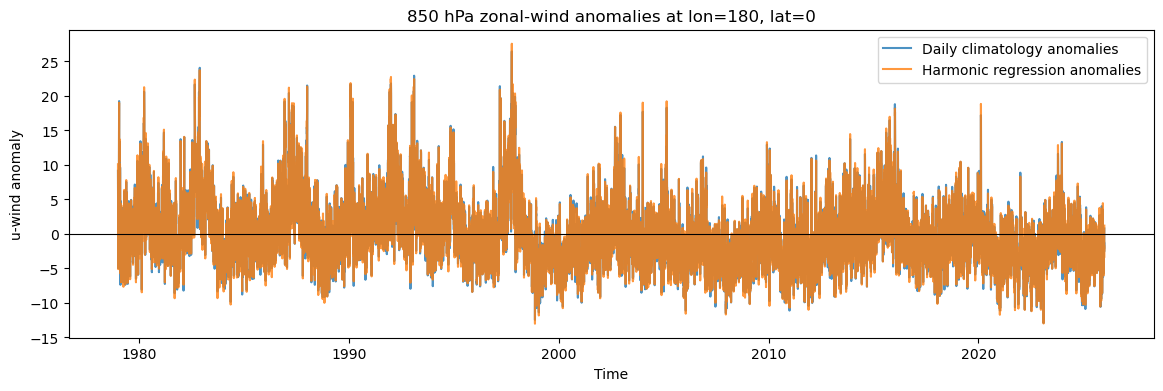

In [49]:
plt.figure(figsize=(14, 4))

daily_point.plot(label="Daily climatology anomalies", alpha=0.8)
harmonic_point.plot(label="Harmonic regression anomalies", alpha=0.8)

plt.axhline(0, color="k", linewidth=0.8)
plt.title("850 hPa zonal-wind anomalies at lon=180, lat=0")
plt.ylabel("u-wind anomaly")
plt.legend()
plt.show()

And if you want to zoom into a shorter time period, say, between 2000 and 2003:

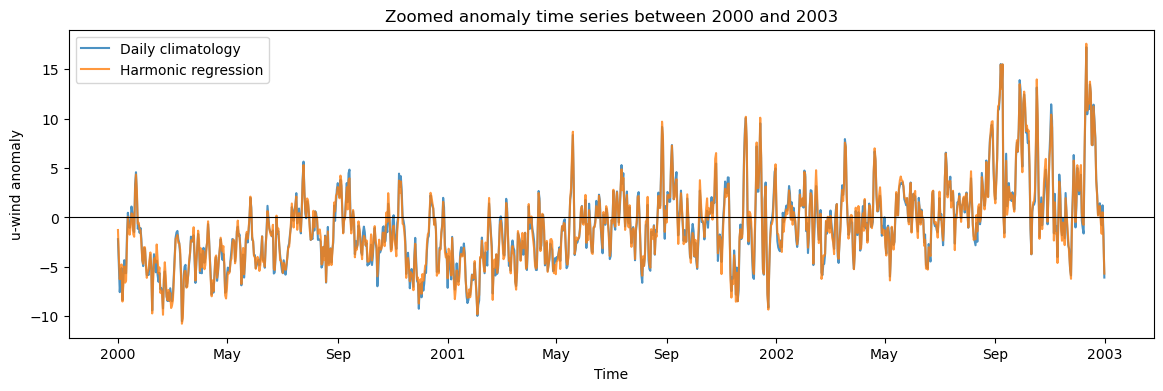

In [51]:
plt.figure(figsize=(14, 4))

daily_point.sel(time=slice("2000-01-01", "2002-12-31")).plot(
    label="Daily climatology", alpha=0.8
)
harmonic_point.sel(time=slice("2000-01-01", "2002-12-31")).plot(
    label="Harmonic regression", alpha=0.8
)

plt.axhline(0, color="k", linewidth=0.8)
plt.title("Zoomed anomaly time series between 2000 and 2003")
plt.ylabel("u-wind anomaly")
plt.legend()
plt.show()

### III. Differences between two methods

If you are curious about the difference between two methods:

In [53]:
daily_aligned, harmonic_aligned = xr.align(daily_anom, harmonic_anom, join="inner")

difference = daily_aligned - harmonic_aligned

:::{note}
Align in case one method dropped Feb 29 or has slightly different times
:::

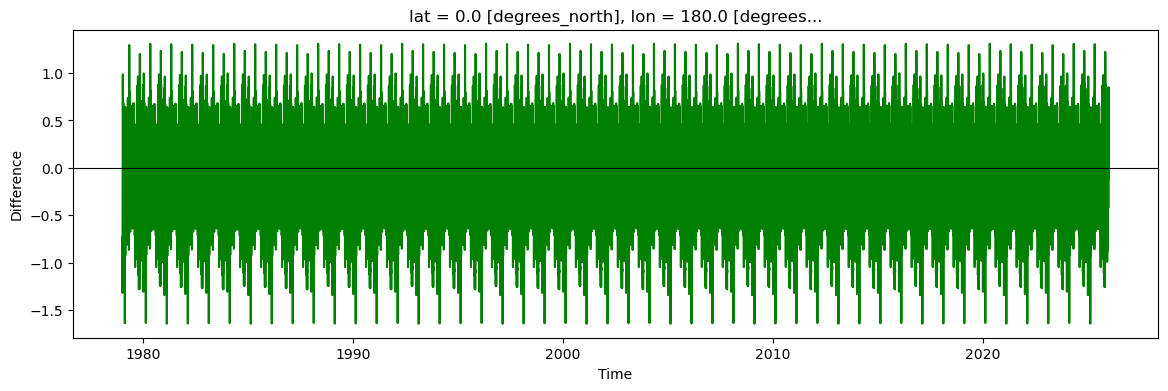

In [57]:
difference_point = difference.sel(lat=lat0, lon=lon0, method="nearest")

plt.figure(figsize=(14, 4))
difference_point.plot(color="green")
plt.axhline(0, color="k", linewidth=0.8)
plt.ylabel("Difference")
plt.show()

For the shorter time period: 

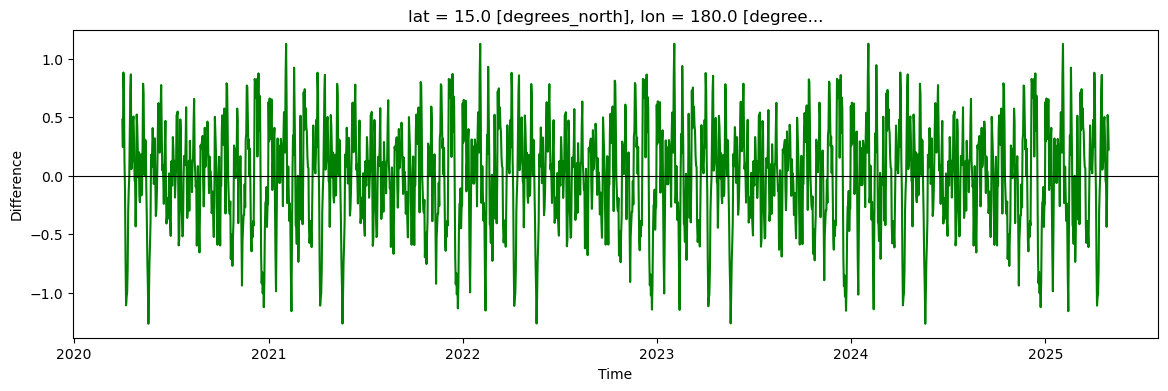

In [62]:
difference_point = difference.sel(lat=15, lon=lon0, method="nearest")
difference_point_sub = difference_point.sel(time=slice("2020-04", "2025-04"))

plt.figure(figsize=(14, 4))
difference_point_sub.plot(color="green")
plt.axhline(0, color="k", linewidth=0.8)
plt.ylabel("Difference")
plt.show()

### IV. Compare regional-mean anomaly time series

For tropical winds, you may want to average over the tropics (e.g., 30°S–30°N).

For this dataset, the latitutde is between 30°S and 30°N, but for global dataset, we need to select the tropical region.

In [63]:
daily_tropics = daily_aligned.sel(lat=slice(30, -30))
harmonic_tropics = harmonic_aligned.sel(lat=slice(30, -30))

Compute cosine-latitude weights:

In [64]:
import numpy as np

weights = np.cos(np.deg2rad(daily_tropics["lat"]))

Area-weighted tropical mean:

In [67]:
daily_tropical_mean = daily_tropics.weighted(weights).mean(("lat", "lon"))
harmonic_tropical_mean = harmonic_tropics.weighted(weights).mean(("lat", "lon"))

Plot:

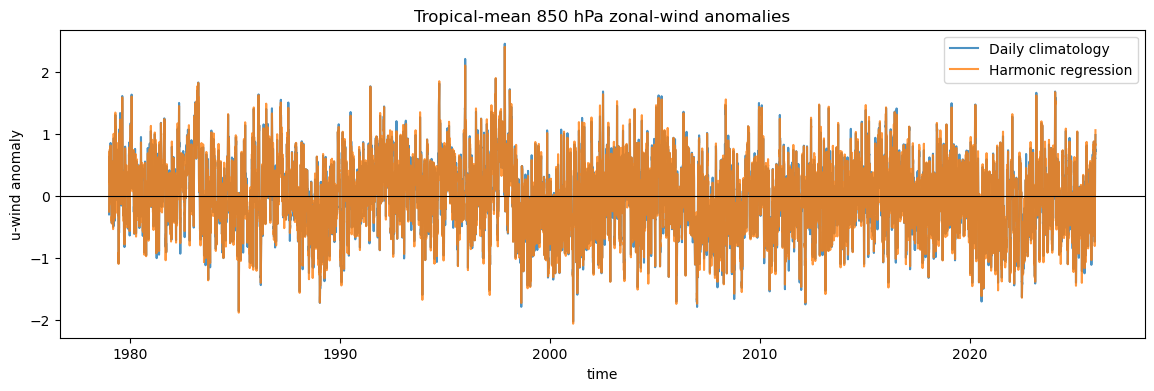

In [69]:
plt.figure(figsize=(14, 4))

daily_tropical_mean.plot(label="Daily climatology", alpha=0.8)
harmonic_tropical_mean.plot(label="Harmonic regression", alpha=0.8)

plt.axhline(0, color="k", linewidth=0.8)
plt.title("Tropical-mean 850 hPa zonal-wind anomalies")
plt.ylabel("u-wind anomaly")
plt.legend()
plt.show()

### V. Check that the anomalies have near-zero mean

Let's check if the time mean should be close to zero. Ideally, both maps should be close to zero. 

In [70]:
daily_mean = daily_aligned.mean("time")
harmonic_mean = harmonic_aligned.mean("time")

Plot:

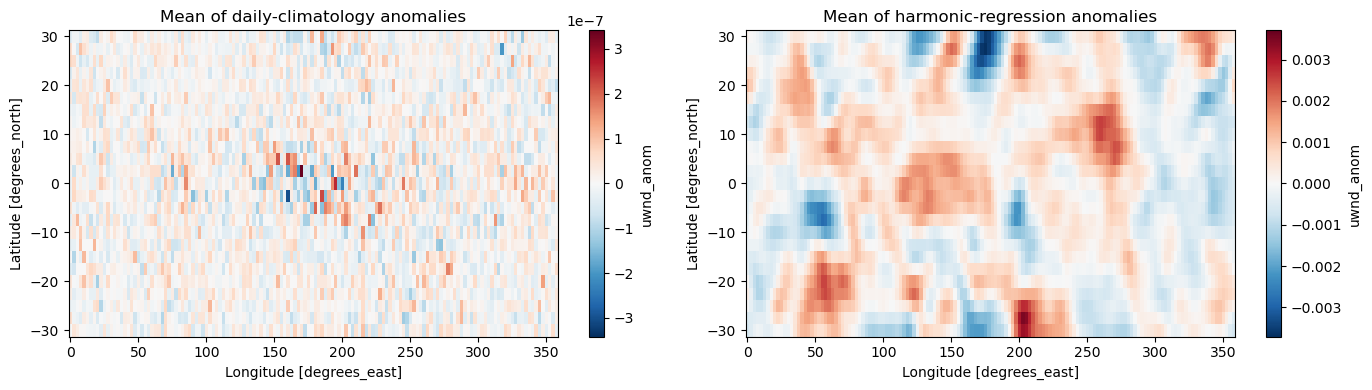

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

daily_mean.plot(ax=axes[0], cmap="RdBu_r")
axes[0].set_title("Mean of daily-climatology anomalies")

harmonic_mean.plot(ax=axes[1], cmap="RdBu_r")
axes[1].set_title("Mean of harmonic-regression anomalies")

plt.tight_layout()
plt.show()

Since the order of magnitude for both is way less than 1, it shows that both anomalies have near-zero mean. 

### VI. Check the remaining seasonal cycle

For the daily climatology method, the average anomaly for each day of year should be close to zero.

In [72]:
daily_residual_seasonal = daily_aligned.groupby("time.dayofyear").mean("time")
harmonic_residual_seasonal = harmonic_aligned.groupby("time.dayofyear").mean("time")

Inspect at one grid point:

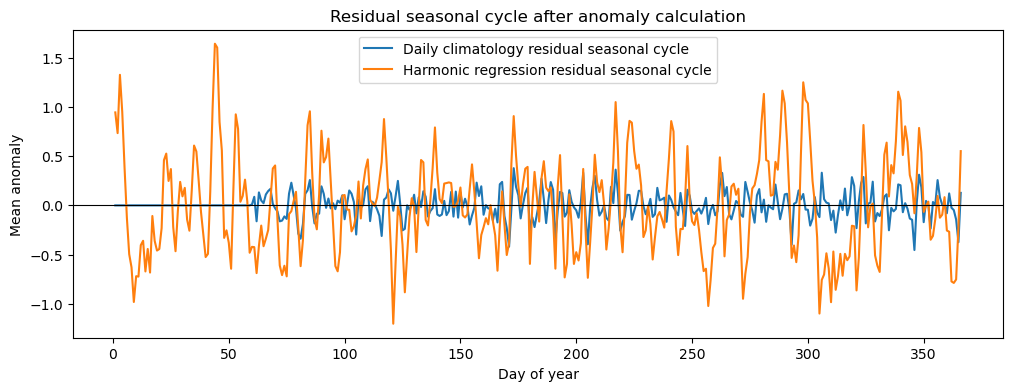

In [75]:
daily_resid_point = daily_residual_seasonal.sel(lat=lat0, lon=lon0, method="nearest")
harmonic_resid_point = harmonic_residual_seasonal.sel(lat=lat0, lon=lon0, method="nearest")

plt.figure(figsize=(12, 4))

daily_resid_point.plot(label="Daily climatology residual seasonal cycle")
harmonic_resid_point.plot(label="Harmonic regression residual seasonal cycle")

plt.axhline(0, color="k", linewidth=0.8)
plt.title("Residual seasonal cycle after anomaly calculation")
plt.xlabel("Day of year")
plt.ylabel("Mean anomaly")
plt.legend()
plt.show()

:::{note}
The daily climatology method has a very small residual seasonal cycle. 
The harmonic method leaves a greater but still small residual because it only removes the seasonal cycle represented by the chosen harmonics.
:::

### VII. Compute correlation and RMSE between methods 

Let's use correlation and RMSE for quantitative validation: 

In [78]:
corr = xr.corr(daily_aligned, harmonic_aligned, dim="time")
rmse = np.sqrt(((daily_aligned - harmonic_aligned) ** 2).mean("time"))

Plot correlation map:

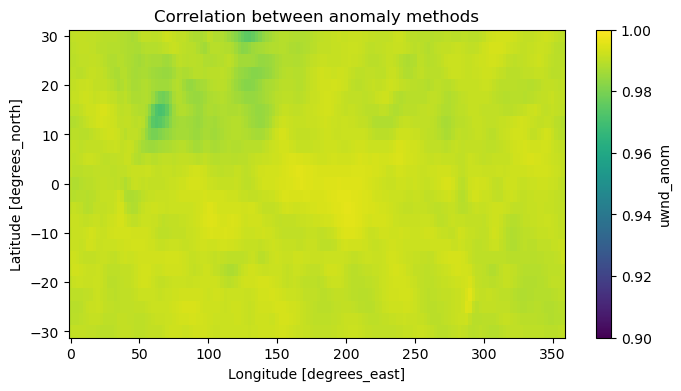

In [79]:
plt.figure(figsize=(8, 4))
corr.plot(vmin=0.9, vmax=1.0, cmap="viridis")
plt.title("Correlation between anomaly methods")
plt.show()

Plot RMSE map:

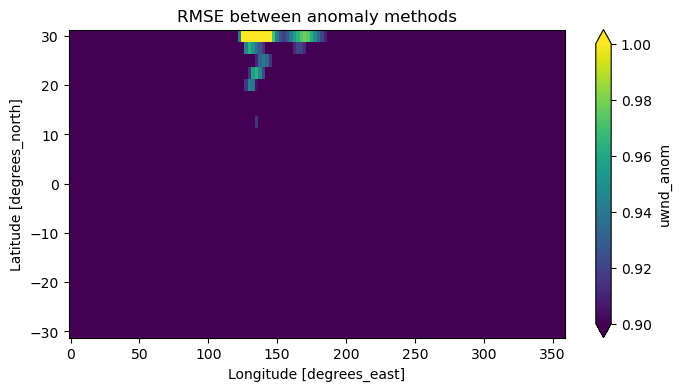

In [81]:
plt.figure(figsize=(8, 4))
rmse.plot(vmin=0.9, vmax=1.0, cmap="viridis")
plt.title("RMSE between anomaly methods")
plt.show()

:::{note}
In general, you should expect the two anomaly time series to look broadly similar. The daily climatology method removes a separate mean for every calendar day, while harmonic regression removes a smoother seasonal cycle.
:::

---

## Summary
Add one final `---` marking the end of your body of content, and then conclude with a brief single paragraph summarizing at a high level the key pieces that were learned and how they tied to your objectives. Look to reiterate what the most important takeaways were.

### What's next?
Let Jupyter book tie this to the next (sequential) piece of content that people could move on to down below and in the sidebar. However, if this page uniquely enables your reader to tackle other nonsequential concepts throughout this book, or even external content, link to it here!

## Resources and references
Finally, be rigorous in your citations and references as necessary. Give credit where credit is due. Also, feel free to link to relevant external material, further reading, documentation, etc. Then you're done! Give yourself a quick review, a high five, and send us a pull request. A few final notes:
 - `Kernel > Restart Kernel and Run All Cells...` to confirm that your notebook will cleanly run from start to finish
 - `Kernel > Restart Kernel and Clear All Outputs...` before committing your notebook, our machines will do the heavy lifting
 - Take credit! Provide author contact information if you'd like; if so, consider adding information here at the bottom of your notebook
 - Give credit! Attribute appropriate authorship for referenced code, information, images, etc.
 - Only include what you're legally allowed: **no copyright infringement or plagiarism**
 
Thank you for your contribution!